

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


Startup de vendas de produtos alimentícios.

--Carregando arquivo--

In [2]:
import pandas as pd

In [10]:
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

--Preparando os dados para análise.--

In [11]:
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [12]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [13]:
logs = logs.rename(columns={
    'EventName': 'event',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'timestamp', 
    'ExpId': 'group'
})

In [14]:
print(logs.head())

                     event              user_id   timestamp  group
0         MainScreenAppear  4575588528974610257  1564029816    246
1         MainScreenAppear  7416695313311560658  1564053102    246
2  PaymentScreenSuccessful  3518123091307005509  1564054127    248
3         CartScreenAppear  3518123091307005509  1564054127    248
4  PaymentScreenSuccessful  6217807653094995999  1564055322    248


In [15]:
print("Valores ausentes por coluna:")
print(logs.isnull().sum())

print(f"\nTotal de valores ausentes: {logs.isnull().sum().sum()}")

Valores ausentes por coluna:
event        0
user_id      0
timestamp    0
group        0
dtype: int64

Total de valores ausentes: 0


In [17]:
logs['timestamp'] = pd.to_datetime(logs['timestamp'], unit='s')

In [18]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  object        
 1   user_id    244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   group      244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


In [19]:
logs.head()

,event,user_id,timestamp,group
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248


In [20]:
logs['date'] = logs['timestamp'].dt.date

In [21]:
logs['hour'] = logs['timestamp'].dt.hour

In [22]:
print(logs[['timestamp', 'date', 'hour']].head())

            timestamp        date  hour
0 2019-07-25 04:43:36  2019-07-25     4
1 2019-07-25 11:11:42  2019-07-25    11
2 2019-07-25 11:28:47  2019-07-25    11
3 2019-07-25 11:28:47  2019-07-25    11
4 2019-07-25 11:48:42  2019-07-25    11


In [23]:
logs['day_of_week'] = logs['timestamp'].dt.dayofweek

logs['day_name'] = logs['timestamp'].dt.day_name()

logs['time'] = logs['timestamp'].dt.time

In [24]:
print(logs.head())

                     event              user_id           timestamp  group  \
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36    246   
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42    246   
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47    248   
3         CartScreenAppear  3518123091307005509 2019-07-25 11:28:47    248   
4  PaymentScreenSuccessful  6217807653094995999 2019-07-25 11:48:42    248   

         date  hour  day_of_week  day_name      time  
0  2019-07-25     4            3  Thursday  04:43:36  
1  2019-07-25    11            3  Thursday  11:11:42  
2  2019-07-25    11            3  Thursday  11:28:47  
3  2019-07-25    11            3  Thursday  11:28:47  
4  2019-07-25    11            3  Thursday  11:48:42  


--Verificação de dados.--

In [25]:
print("Eventos únicos:")
print(logs['event'].unique())

print("Grupos de experimento:")
print(logs['group'].unique())

Eventos únicos:
['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']
Grupos de experimento:
[246 248 247]


Temos um total de 5 eventos únicos. No dataset, podemos ver que há 244.126 eventos registrados no total. Isso significa que foram capturadas 244.126 ações individuais de usuários durante o período analisado.

In [26]:
total_usuarios = logs['user_id'].nunique()
print(f"Total de usuários únicos: {total_usuarios}")

Total de usuários únicos: 7551


In [27]:
eventos_por_usuario = len(logs) / total_usuarios
print(f"Eventos por usuário (média): {eventos_por_usuario:.2f}")

eventos_por_usuario_dist = logs.groupby('user_id').size()
print(f"Usuário mais ativo teve {eventos_por_usuario_dist.max()} eventos")
print(f"Usuário menos ativo teve {eventos_por_usuario_dist.min()} eventos")

Eventos por usuário (média): 32.33
Usuário mais ativo teve 2308 eventos
Usuário menos ativo teve 1 eventos


In [36]:
users_per_group = logs.groupby('group')['user_id'].nunique()
print(users_per_group)

group
246    2489
247    2520
248    2542
Name: user_id, dtype: int64


Os dados apresentam 7.551 usuários únicos distribuídos em 244.126 registros, com média de 32,33 eventos por usuário. O grupo 248 (grupo de teste) é o que apresenta o maior número de registros, totalizando 2.542.

In [29]:
data_min = logs['timestamp'].min()
data_max = logs['timestamp'].max()
print(f"Data mínima: {data_min}")
print(f"Data máxima: {data_max}")
print(f"Período total: {(data_max - data_min).days} dias")

Data mínima: 2019-07-25 04:43:36
Data máxima: 2019-08-07 21:15:17
Período total: 13 dias




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>


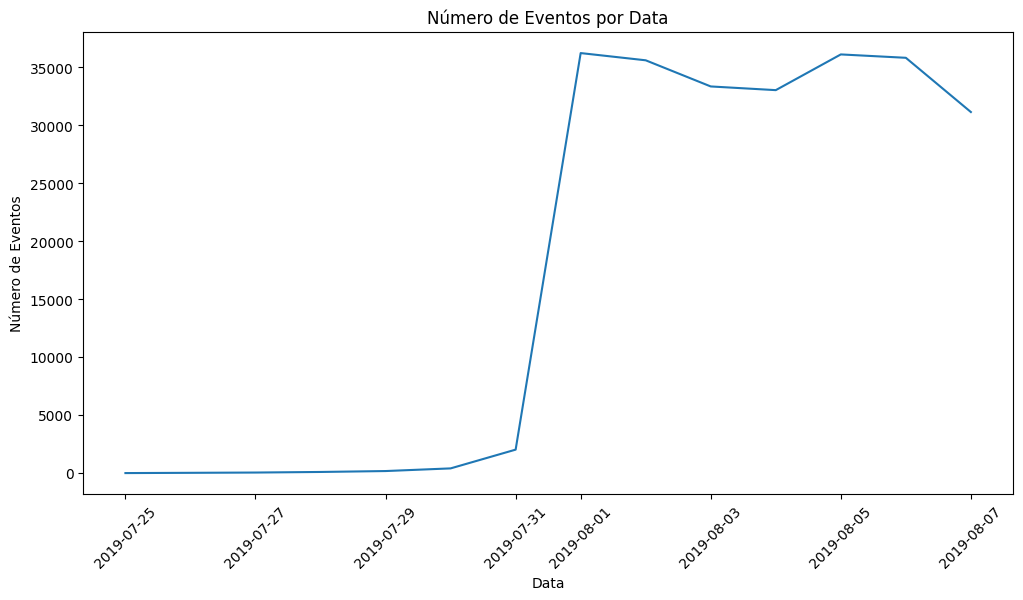

In [30]:
import matplotlib.pyplot as plt

logs_por_data = logs.groupby('date').size()
plt.figure(figsize=(12, 6))
plt.plot(logs_por_data.index, logs_por_data.values)
plt.title('Número de Eventos por Data')
plt.xlabel('Data')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.show()

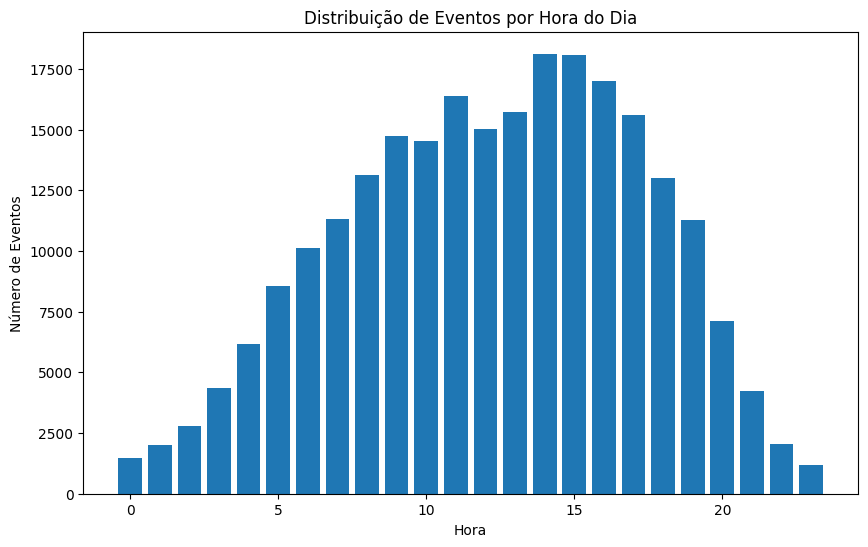

In [31]:
eventos_por_hora = logs.groupby('hour').size()
plt.figure(figsize=(10, 6))
plt.bar(eventos_por_hora.index, eventos_por_hora.values)
plt.title('Distribuição de Eventos por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')
plt.show()

In [33]:
print("Eventos ANTES de 30/07/2019:")
logs_antes = logs[logs['date'] < pd.to_datetime('2019-07-30').date()]
print(f"Total: {len(logs_antes)} eventos")
print(f"Usuários únicos: {logs_antes['user_id'].nunique()}")

print("\nEventos A PARTIR de 30/07/2019:")
logs_depois = logs[logs['date'] >= pd.to_datetime('2019-07-30').date()]
print(f"Total: {len(logs_depois)} eventos")
print(f"Usuários únicos: {logs_depois['user_id'].nunique()}")

Eventos ANTES de 30/07/2019:
Total: 384 eventos
Usuários únicos: 266

Eventos A PARTIR de 30/07/2019:
Total: 243742 eventos
Usuários únicos: 7547


In [34]:
logs_limpos = logs[logs['date'] >= pd.to_datetime('2019-07-30').date()].copy()
print(f"Dataset limpo: {len(logs_limpos)} eventos de {logs_limpos['user_id'].nunique()} usuários")
print(f"Período: {logs_limpos['date'].min()} até {logs_limpos['date'].max()}")

Dataset limpo: 243742 eventos de 7547 usuários
Período: 2019-07-30 até 2019-08-07


Foram eliminados 384 eventos durante a fase de teste.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>
Dataset foi limpo e volumetria após ajuste foi investigada conforme roteiro!
</div>


O número de eventos passa a crescer a partir de 30/07/2019, possivelmente devido ao fato de os primeiros dias corresponderem a uma fase de teste. As horas de maior movimento ocorrem entre 7h e 19h.

--Funil de eventos--

In [37]:
frequencia_eventos = logs_limpos['event'].value_counts()
print("Frequência dos eventos (ordenados por quantidade):")
print(frequencia_eventos)

Frequência dos eventos (ordenados por quantidade):
MainScreenAppear           118961
OffersScreenAppear          46775
CartScreenAppear            42672
PaymentScreenSuccessful     34286
Tutorial                     1048
Name: event, dtype: int64


In [38]:
percentual_eventos = logs_limpos['event'].value_counts(normalize=True) * 100
print("\nPercentual de cada evento:")
print(percentual_eventos.round(2))


Percentual de cada evento:
MainScreenAppear           48.81
OffersScreenAppear         19.19
CartScreenAppear           17.51
PaymentScreenSuccessful    14.07
Tutorial                    0.43
Name: event, dtype: float64


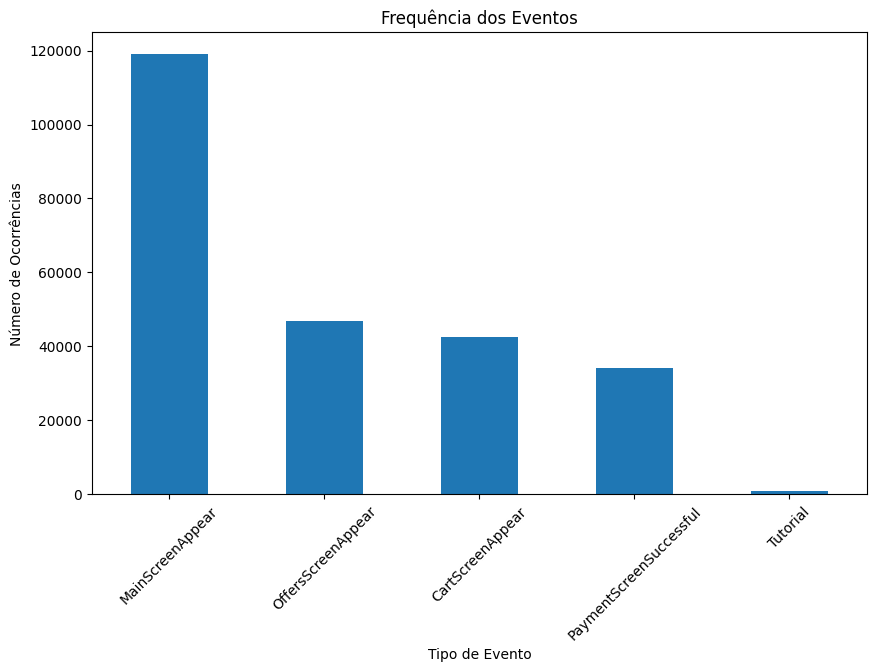

In [39]:
plt.figure(figsize=(10, 6))
frequencia_eventos.plot(kind='bar')
plt.title('Frequência dos Eventos')
plt.xlabel('Tipo de Evento')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45)
plt.show()

In [40]:
usuarios_por_evento = logs_limpos.groupby('event')['user_id'].nunique()
print("Usuários únicos por evento:")
print(usuarios_por_evento.sort_values(ascending=False))

Usuários únicos por evento:
event
MainScreenAppear           7435
OffersScreenAppear         4612
CartScreenAppear           3747
PaymentScreenSuccessful    3546
Tutorial                    845
Name: user_id, dtype: int64


In [41]:
total_usuarios = logs_limpos['user_id'].nunique()
proporcao_usuarios = (usuarios_por_evento / total_usuarios * 100).round(2)
print(f"\nTotal de usuários únicos: {total_usuarios}")
print("\nProporção de usuários que executaram cada ação:")
print(proporcao_usuarios.sort_values(ascending=False))


Total de usuários únicos: 7547

Proporção de usuários que executaram cada ação:
event
MainScreenAppear           98.52
OffersScreenAppear         61.11
CartScreenAppear           49.65
PaymentScreenSuccessful    46.99
Tutorial                   11.20
Name: user_id, dtype: float64


In [42]:
resumo_eventos = pd.DataFrame({
    'usuarios_unicos': usuarios_por_evento,
    'proporcao_usuarios': proporcao_usuarios
}).sort_values('usuarios_unicos', ascending=False)
print(resumo_eventos)

                         usuarios_unicos  proporcao_usuarios
event                                                       
MainScreenAppear                    7435               98.52
OffersScreenAppear                  4612               61.11
CartScreenAppear                    3747               49.65
PaymentScreenSuccessful             3546               46.99
Tutorial                             845               11.20


A sequência principal representa o fluxo esperado de navegação do utilizador dentro do funil de compra, desde a abertura do app até à finalização da compra. Esse encadeamento ajuda a analisar o comportamento típico e identificar possíveis pontos de perda entre etapas.

No entanto, o evento “Tutorial” não faz parte dessa sequência, pois trata-se de uma ação independente que pode ser realizada a qualquer momento pelo utilizador, sem relação direta com o processo de compra. Por isso, ele deve ser tratado separadamente na análise, já que não pertence ao funil principal de conversão.

MainScreen → Offers → Cart → Payment

In [43]:
funil_sequencia = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

usuarios_funil = usuarios_por_evento[funil_sequencia]
print("Usuários por etapa do funil:")
print(usuarios_funil)

Usuários por etapa do funil:
event
MainScreenAppear           7435
OffersScreenAppear         4612
CartScreenAppear           3747
PaymentScreenSuccessful    3546
Name: user_id, dtype: int64


In [45]:
taxas_conversao = []
nomes_etapas = []

for i in range(len(funil_sequencia) - 1):
    etapa_atual = funil_sequencia[i]
    proxima_etapa = funil_sequencia[i + 1]
    
    usuarios_atual = usuarios_funil[etapa_atual]
    usuarios_proxima = usuarios_funil[proxima_etapa]
    
    taxa = (usuarios_proxima / usuarios_atual) * 100
    taxas_conversao.append(taxa)
    nomes_etapas.append(f"{etapa_atual} → {proxima_etapa}")

for nome, taxa in zip(nomes_etapas, taxas_conversao):
    print(f"{nome}: {taxa:.2f}%")

MainScreenAppear → OffersScreenAppear: 62.03%
OffersScreenAppear → CartScreenAppear: 81.24%
CartScreenAppear → PaymentScreenSuccessful: 94.64%


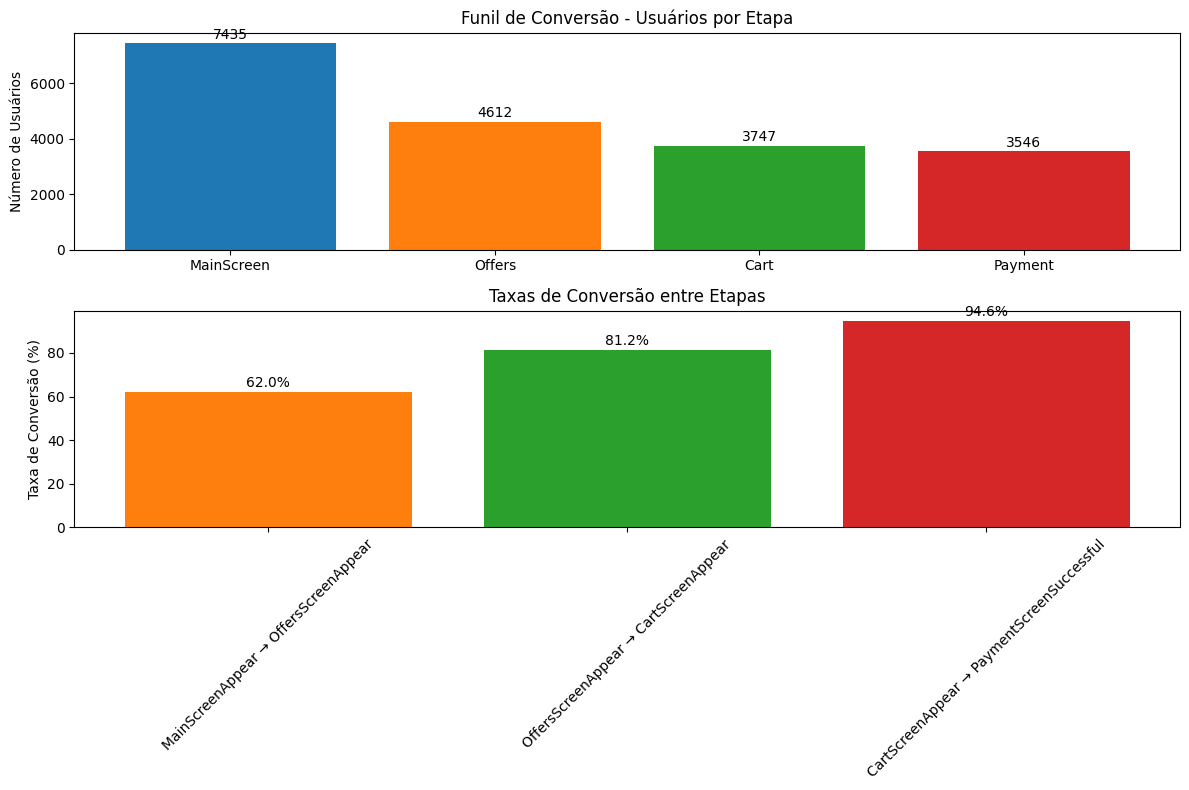

In [46]:
plt.figure(figsize=(12, 8))

etapas = ['MainScreen', 'Offers', 'Cart', 'Payment']
usuarios = [usuarios_funil[evento] for evento in funil_sequencia]

plt.subplot(2, 1, 1)
bars = plt.bar(etapas, usuarios, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Funil de Conversão - Usuários por Etapa')
plt.ylabel('Número de Usuários')

for bar, valor in zip(bars, usuarios):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(valor), ha='center', va='bottom')

plt.subplot(2, 1, 2)
plt.bar(nomes_etapas, taxas_conversao, color=['#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Taxas de Conversão entre Etapas')
plt.ylabel('Taxa de Conversão (%)')
plt.xticks(rotation=45)

for i, taxa in enumerate(taxas_conversao):
    plt.text(i, taxa + 1, f'{taxa:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Perdemos mais usuários na fase das 'Ofertas'.

In [49]:
usuarios_inicio = usuarios_funil['MainScreenAppear']        
usuarios_fim = usuarios_funil['PaymentScreenSuccessful']   

conversao_total = (usuarios_fim / usuarios_inicio) * 100

print(f"Conversão total do funil: {conversao_total:.2f}%")
print(f"De {usuarios_inicio:,} usuários que viram a tela principal,")
print(f"apenas {usuarios_fim:,} completaram o pagamento")

Conversão total do funil: 47.69%
De 7,435 usuários que viram a tela principal,
apenas 3,546 completaram o pagamento




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Funil de conversão foi devidamente investigado com gráficos e conslusões adequados.
</div>


--Resultados do experimento--

In [51]:
users_per_group = logs.groupby('group')['user_id'].nunique()
print(users_per_group)

group
246    2489
247    2520
248    2542
Name: user_id, dtype: int64


In [52]:
grupo_246 = logs_limpos[logs_limpos['group'] == 246]
grupo_247 = logs_limpos[logs_limpos['group'] == 247]

def calcular_conversao_grupo(dados_grupo):
    usuarios_main = dados_grupo[dados_grupo['event'] == 'MainScreenAppear']['user_id'].nunique()
    usuarios_payment = dados_grupo[dados_grupo['event'] == 'PaymentScreenSuccessful']['user_id'].nunique()
    taxa_conversao = (usuarios_payment / usuarios_main) * 100 if usuarios_main > 0 else 0
    return usuarios_main, usuarios_payment, taxa_conversao

In [53]:
main_246, payment_246, conversao_246 = calcular_conversao_grupo(grupo_246)
 
main_247, payment_247, conversao_247 = calcular_conversao_grupo(grupo_247)

print("=== TESTE A/A - GRUPOS DE CONTROLE ===")
print(f"\nGrupo 246:")
print(f"  Usuários MainScreen: {main_246}")
print(f"  Usuários Payment: {payment_246}")
print(f"  Taxa de conversão: {conversao_246:.2f}%")

print(f"\nGrupo 247:")
print(f"  Usuários MainScreen: {main_247}")
print(f"  Usuários Payment: {payment_247}")
print(f"  Taxa de conversão: {conversao_247:.2f}%")

print(f"\nDiferença entre grupos: {abs(conversao_246 - conversao_247):.2f} pontos percentuais")

=== TESTE A/A - GRUPOS DE CONTROLE ===

Grupo 246:
  Usuários MainScreen: 2454
  Usuários Payment: 1202
  Taxa de conversão: 48.98%

Grupo 247:
  Usuários MainScreen: 2482
  Usuários Payment: 1160
  Taxa de conversão: 46.74%

Diferença entre grupos: 2.24 pontos percentuais


In [55]:
import numpy as np
from scipy import stats

n1, x1 = main_246, payment_246 
n2, x2 = main_247, payment_247 

p1 = x1 / n1
p2 = x2 / n2

p_combined = (x1 + x2) / (n1 + n2)

se = np.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

z_stat = (p1 - p2) / se

p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Estatística Z: {z_stat:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Significativo (α=0.05)? {'Sim' if p_value < 0.05 else 'Não'}")

Estatística Z: 1.5785
P-valor: 0.1144
Significativo (α=0.05)? Não


Não há diferença estatisticamente significativa entre os grupos 246 e 247.
A diferença de 2.24 pontos percentuais é apenas variação natural/aleatória.

In [57]:
def analisar_evento_grupos(dados, evento, grupo1=246, grupo2=247):
    """
    Analisa um evento específico entre dois grupos e testa significância estatística
    """
    # Filtrar dados para cada grupo
    dados_grupo1 = dados[dados['group'] == grupo1]
    dados_grupo2 = dados[dados['group'] == grupo2]
    
    # Contar usuários únicos que fizeram o evento
    usuarios_evento_g1 = dados_grupo1[dados_grupo1['event'] == evento]['user_id'].nunique()
    usuarios_evento_g2 = dados_grupo2[dados_grupo2['event'] == evento]['user_id'].nunique()
    
    # Total de usuários em cada grupo
    total_usuarios_g1 = dados_grupo1['user_id'].nunique()
    total_usuarios_g2 = dados_grupo2['user_id'].nunique()
    
    # Calcular proporções
    prop_g1 = usuarios_evento_g1 / total_usuarios_g1
    prop_g2 = usuarios_evento_g2 / total_usuarios_g2
    
    # Teste de significância (teste Z para proporções)
    p_combined = (usuarios_evento_g1 + usuarios_evento_g2) / (total_usuarios_g1 + total_usuarios_g2)
    se = np.sqrt(p_combined * (1 - p_combined) * (1/total_usuarios_g1 + 1/total_usuarios_g2))
    z_stat = (prop_g1 - prop_g2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    return {
        'evento': evento,
        'grupo1_usuarios': usuarios_evento_g1,
        'grupo1_total': total_usuarios_g1,
        'grupo1_proporcao': prop_g1,
        'grupo2_usuarios': usuarios_evento_g2,
        'grupo2_total': total_usuarios_g2,
        'grupo2_proporcao': prop_g2,
        'diferenca_prop': abs(prop_g1 - prop_g2),
        'z_statistic': z_stat,
        'p_value': p_value,
        'significativo': p_value < 0.05
    }

In [61]:
resultado = analisar_evento_grupos(logs_limpos, 'MainScreenAppear')
print(f"Evento: {resultado['evento']}")
print(f"Grupo 246: {resultado['grupo1_usuarios']}/{resultado['grupo1_total']} = {resultado['grupo1_proporcao']:.4f}")
print(f"Grupo 247: {resultado['grupo2_usuarios']}/{resultado['grupo2_total']} = {resultado['grupo2_proporcao']:.4f}")
print(f"Diferença: {resultado['diferenca_prop']:.4f}")
print(f"P-valor: {resultado['p_value']:.4f}")
print(f"Significativo: {resultado['significativo']}")

Evento: MainScreenAppear
Grupo 246: 2454/2487 = 0.9867
Grupo 247: 2482/2520 = 0.9849
Diferença: 0.0018
P-valor: 0.5880
Significativo: False


Não significativo: Confirma que os grupos são estatisticamente equivalentes

In [62]:
eventos_unicos = logs_limpos['event'].unique()
print(f"Eventos a serem analisados: {list(eventos_unicos)}")

resultados_aa = []

print("\n=== ANÁLISE A/A - TODOS OS EVENTOS ===\n")

for evento in eventos_unicos:
    resultado = analisar_evento_grupos(logs_limpos, evento)
    resultados_aa.append(resultado)
    
    print(f"📊 {evento}")
    print(f"   Grupo 246: {resultado['grupo1_usuarios']:,}/{resultado['grupo1_total']:,} = {resultado['grupo1_proporcao']:.4f}")
    print(f"   Grupo 247: {resultado['grupo2_usuarios']:,}/{resultado['grupo2_total']:,} = {resultado['grupo2_proporcao']:.4f}")
    print(f"   Diferença: {resultado['diferenca_prop']:.4f}")
    print(f"   P-valor: {resultado['p_value']:.4f}")
    print(f"   Significativo: {'❌ SIM' if resultado['significativo'] else '✅ NÃO'}")
    print()

Eventos a serem analisados: ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']

=== ANÁLISE A/A - TODOS OS EVENTOS ===

📊 MainScreenAppear
   Grupo 246: 2,454/2,487 = 0.9867
   Grupo 247: 2,482/2,520 = 0.9849
   Diferença: 0.0018
   P-valor: 0.5880
   Significativo: ✅ NÃO

📊 OffersScreenAppear
   Grupo 246: 1,545/2,487 = 0.6212
   Grupo 247: 1,529/2,520 = 0.6067
   Diferença: 0.0145
   P-valor: 0.2925
   Significativo: ✅ NÃO

📊 CartScreenAppear
   Grupo 246: 1,269/2,487 = 0.5103
   Grupo 247: 1,240/2,520 = 0.4921
   Diferença: 0.0182
   P-valor: 0.1981
   Significativo: ✅ NÃO

📊 PaymentScreenSuccessful
   Grupo 246: 1,202/2,487 = 0.4833
   Grupo 247: 1,160/2,520 = 0.4603
   Diferença: 0.0230
   P-valor: 0.1032
   Significativo: ✅ NÃO

📊 Tutorial
   Grupo 246: 278/2,487 = 0.1118
   Grupo 247: 285/2,520 = 0.1131
   Diferença: 0.0013
   P-valor: 0.8830
   Significativo: ✅ NÃO



In [65]:
resultado_248_vs_246 = analisar_evento_grupos(logs_limpos, 'MainScreenAppear', grupo1=248, grupo2=246)
resultado_248_vs_247 = analisar_evento_grupos(logs_limpos, 'MainScreenAppear', grupo1=248, grupo2=247)

In [66]:
eventos_unicos = logs_limpos['event'].unique()

print("=== ANÁLISE A/B - GRUPO 248 (FONTES ALTERADAS) ===\n")

# Comparação 248 vs 246
print("🔍 GRUPO 248 vs GRUPO 246")
print("=" * 50)
for evento in eventos_unicos:
    resultado = analisar_evento_grupos(logs_limpos, evento, grupo1=248, grupo2=246)
    print(f"📊 {evento}")
    print(f"   Grupo 248: {resultado['grupo1_usuarios']:,}/{resultado['grupo1_total']:,} = {resultado['grupo1_proporcao']:.4f}")
    print(f"   Grupo 246: {resultado['grupo2_usuarios']:,}/{resultado['grupo2_total']:,} = {resultado['grupo2_proporcao']:.4f}")
    print(f"   Diferença: {resultado['diferenca_prop']:.4f}")
    print(f"   P-valor: {resultado['p_value']:.4f}")
    print(f"   Significativo: {'✅ SIM' if resultado['significativo'] else '❌ NÃO'}")
    print()

print("\n" + "=" * 60)

# Comparação 248 vs 247
print("🔍 GRUPO 248 vs GRUPO 247")
print("=" * 50)
for evento in eventos_unicos:
    resultado = analisar_evento_grupos(logs_limpos, evento, grupo1=248, grupo2=247)
    print(f"📊 {evento}")
    print(f"   Grupo 248: {resultado['grupo1_usuarios']:,}/{resultado['grupo1_total']:,} = {resultado['grupo1_proporcao']:.4f}")
    print(f"   Grupo 247: {resultado['grupo2_usuarios']:,}/{resultado['grupo2_total']:,} = {resultado['grupo2_proporcao']:.4f}")
    print(f"   Diferença: {resultado['diferenca_prop']:.4f}")
    print(f"   P-valor: {resultado['p_value']:.4f}")
    print(f"   Significativo: {'✅ SIM' if resultado['significativo'] else '❌ NÃO'}")
    print()

=== ANÁLISE A/B - GRUPO 248 (FONTES ALTERADAS) ===

🔍 GRUPO 248 vs GRUPO 246
📊 MainScreenAppear
   Grupo 248: 2,499/2,540 = 0.9839
   Grupo 246: 2,454/2,487 = 0.9867
   Diferença: 0.0029
   P-valor: 0.3978
   Significativo: ❌ NÃO

📊 OffersScreenAppear
   Grupo 248: 1,538/2,540 = 0.6055
   Grupo 246: 1,545/2,487 = 0.6212
   Diferença: 0.0157
   P-valor: 0.2526
   Significativo: ❌ NÃO

📊 CartScreenAppear
   Grupo 248: 1,238/2,540 = 0.4874
   Grupo 246: 1,269/2,487 = 0.5103
   Diferença: 0.0229
   P-valor: 0.1052
   Significativo: ❌ NÃO

📊 PaymentScreenSuccessful
   Grupo 248: 1,184/2,540 = 0.4661
   Grupo 246: 1,202/2,487 = 0.4833
   Diferença: 0.0172
   P-valor: 0.2229
   Significativo: ❌ NÃO

📊 Tutorial
   Grupo 248: 282/2,540 = 0.1110
   Grupo 246: 278/2,487 = 0.1118
   Diferença: 0.0008
   P-valor: 0.9320
   Significativo: ❌ NÃO


🔍 GRUPO 248 vs GRUPO 247
📊 MainScreenAppear
   Grupo 248: 2,499/2,540 = 0.9839
   Grupo 247: 2,482/2,520 = 0.9849
   Diferença: 0.0011
   P-valor: 0.7605
 

A alteração das fontes (grupo 248) NÃO teve impacto significativo em nenhum dos eventos analisados. Isso significa que a mudança de fontes não afetou o comportamento dos usuários.

In [68]:
alpha_original = 0.05
num_testes = 15
alpha_corrigido = alpha_original / num_testes

print(f"Nível de significância original: {alpha_original}")
print(f"Número total de testes: {num_testes}")
print(f"Nível de significância corrigido (Bonferroni): {alpha_corrigido:.4f}")

print(f"\nCom α = {alpha_corrigido:.4f}, algum teste seria significativo?")
print("(Todos os seus p-valores foram > 0.05, então a resposta é NÃO)")

Nível de significância original: 0.05
Número total de testes: 15
Nível de significância corrigido (Bonferroni): 0.0033

Com α = 0.0033, algum teste seria significativo?
(Todos os seus p-valores foram > 0.05, então a resposta é NÃO)


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>



--Conclusão--

Com base na análise estatística dos dados, conclui-se que a alteração de fontes implementada no grupo 248 não produziu impacto significativo no comportamento dos utilizadores nem nas taxas de conversão. O funil de utilização evidencia que a principal perda ocorre na transição entre a tela principal e a tela de ofertas, representando o maior ponto de desistência do processo. Além disso, os grupos experimentais encontram-se devidamente equilibrados, o que reforça a validade dos resultados obtidos.

Desta forma, recomenda-se priorizar otimizações na etapa “Offers”, onde existe maior potencial de melhoria da conversão.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Conclusão alinhada aos comportamentos observados ao longo do projeto.
</div>

